In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


from pmlb import fetch_data
from pmlb import regression_dataset_names

def test_dataset(df_o:pd.DataFrame, X_col:str, y_col:str):
    columns = [X_col, y_col]
    df = df_o[columns].dropna()

    X, y = np.asarray(df[[X_col]]), np.asarray(df[y_col])
    sns.scatterplot(data=df, y=y_col, x=X_col)
    
    data = {'X': X.reshape(1,-1)[0],'y': y}
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    model = LinearRegression().fit(X_train, y_train)
    print(model.score(X_test, y_test))

The dataset captures a fundamental photochemical relationship in atmospheric chemistry: the nonlinear formation of ground-level ozone (O₃) from nitrogen oxides (NOx) under solar radiation . NOx—comprising nitric oxide (NO) and nitrogen dioxide (NO₂)—acts as a catalyst in ozone formation, while volatile organic compounds (VOCs) serve as the fuel that drives the reaction cycle . The relationship is inherently nonlinear because ozone production depends on the NOx-to-VOC ratio: in NOx-rich regimes, ozone increases with NOx, but under VOC-limited conditions, additional NOx can actually suppress ozone through titration effects where NO consumes O₃ directly . This chemical complexity—where NOx simultaneously promotes and destroys ozone depending on local concentrations and sunlight intensity—makes linear regression inadequate for capturing the true dynamics . The data, collected from an urban Italian roadside location between March 2004 and February 2005, provides real-world measurements of this photochemical smog process, which remains a critical public health and regulatory challenge globally

In [65]:
df_o

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


0.6293915854859811


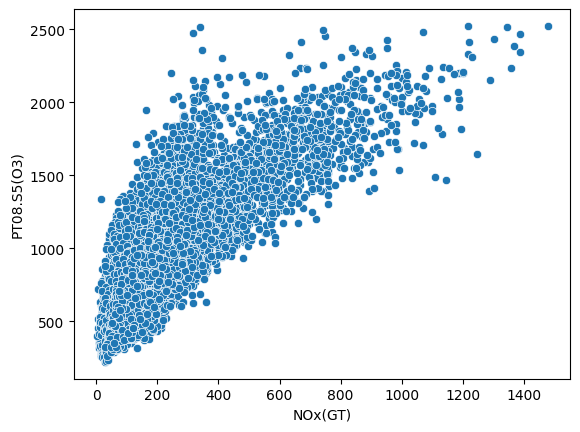

In [64]:
filepath = "../data/UCI Air Quality/AirQualityUCI.csv"
df_o = pd.read_csv(filepath, sep=";")
df_o = df_o.replace(-200, np.nan)

X_col = 'NOx(GT)'
y_col = 'PT08.S5(O3)'
test_dataset(df_o, X_col, y_col)

0.3154828402035046


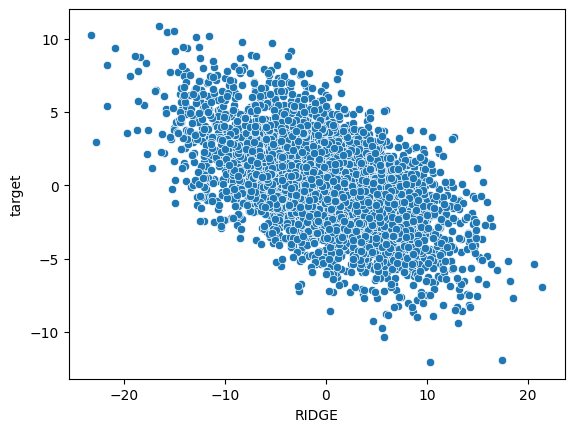

In [13]:
df_o = fetch_data('529_pollen')

X_col = 'RIDGE'
y_col = 'target'
test_dataset(df_o, X_col, y_col)

0.254262554583372


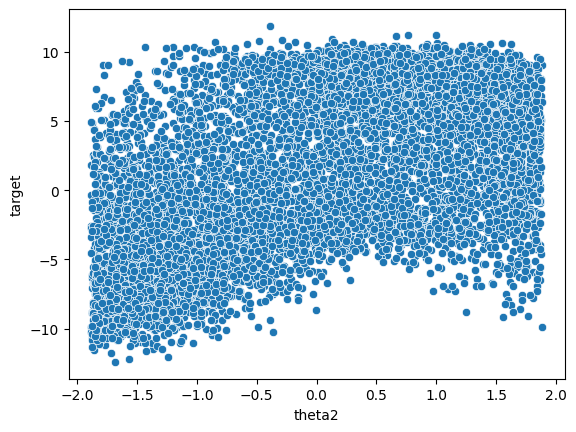

In [30]:
df_o = fetch_data('225_puma8NH')

X_col = 'theta2'
y_col = 'target'
test_dataset(df_o, X_col, y_col)

0.01366386389922536


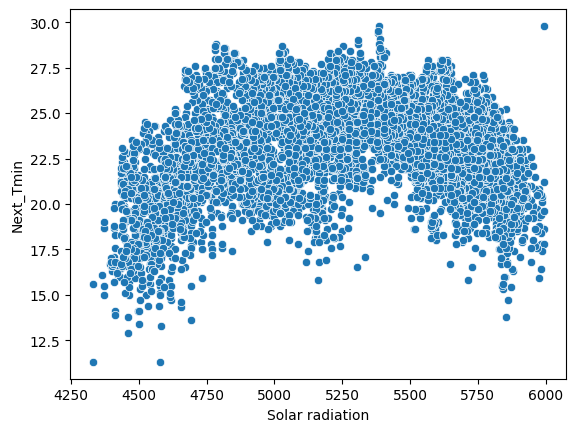

In [44]:
filepath='../data/bias+correction+of+numerical+prediction+model+temperature+forecast/Bias_correction_ucl.csv'
df_o = pd.read_csv(filepath)

X_col = 'Solar radiation'
y_col = 'Next_Tmin'
test_dataset(df_o, X_col, y_col)

0.7651981388137586


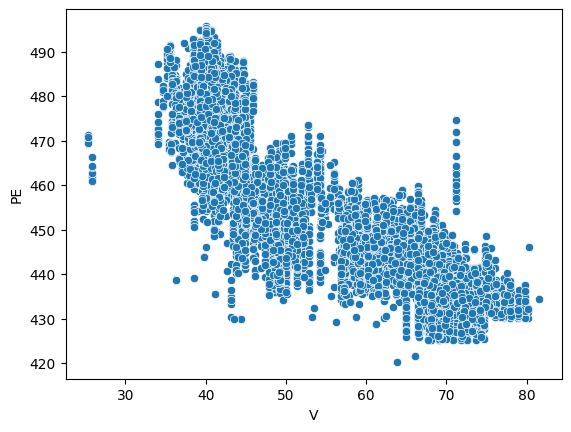

In [51]:
filepath='../data/combined+cycle+power+plant/CCPP/Folds5x2_pp.xlsx'
df_o = pd.read_excel(filepath)

X_col = 'V'
y_col = 'PE'
test_dataset(df_o, X_col, y_col)

In [52]:
from sklearn.model_selection import train_test_split

df = df_o[[X_col, y_col]].dropna()

X = np.asarray(df[[X_col]])
y = np.asarray(df[y_col])

data = {'X': X.reshape(1,-1)[0],'y': y}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

data_train = {'X': X_train.reshape(1,-1)[0],'y': y_train}
data_test = {'X': X_test.reshape(1,-1)[0],'y': y_test}

## Simple Linear Regression

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)
model.score(X_test, y_test)

0.7651981388137586

## KNN

In [54]:
from sklearn.neighbors import KNeighborsRegressor

# KNN Regression
model = KNeighborsRegressor(n_neighbors=60)  # You can adjust k value
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8223788705894395

## Kernel KNN

In [55]:
# Create a custom kernel-weighted KNN
# Using distance-weighted KNN (which is essentially a kernel KNN with a linear kernel)
model = KNeighborsRegressor(n_neighbors=5, weights='distance')  # 'distance' weights points by inverse distance

# For specific kernel functions, you'd need to implement custom weighting
# Example of Gaussian kernel weights:
class KernelKNN:
    def __init__(self, n_neighbors=5, kernel='gaussian', bandwidth=1.0):
        self.n_neighbors = n_neighbors
        self.kernel = kernel
        self.bandwidth = bandwidth
        self.knn = KNeighborsRegressor(n_neighbors=n_neighbors, algorithm='auto')
    
    def fit(self, X, y):
        self.knn.fit(X, y)
        self.X_train = X
        self.y_train = y
        return self
    
    def predict(self, X):
        # Get distances and indices of k nearest neighbors
        distances, indices = self.knn.kneighbors(X)
        
        # Apply kernel weighting
        if self.kernel == 'gaussian':
            weights = np.exp(-distances**2 / (2 * self.bandwidth**2))
        elif self.kernel == 'epanechnikov':
            weights = 0.75 * (1 - (distances/self.bandwidth)**2)
            weights[distances > self.bandwidth] = 0
        else:  # uniform
            weights = np.ones_like(distances)
        
        # Normalize weights
        weights = weights / weights.sum(axis=1, keepdims=True)
        
        # Make predictions
        predictions = np.zeros(len(X))
        for i in range(len(X)):
            predictions[i] = np.sum(weights[i] * self.y_train[indices[i]])
        
        return predictions

# Usage
model = KernelKNN(n_neighbors=5, kernel='gaussian', bandwidth=1.0)
model.fit(X_train, y_train)
# model.score(X_test, y_test)

## Nadaraya-Watson

In [56]:
class NadarayaWatson:
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def _kernel_function(self, distances):
        if self.kernel == 'gaussian':
            return np.exp(-distances**2 / (2 * **2))
        elif self.kernel == 'epanechnikov':
            weights = 0.75 * (1 - (distances/self.bandwidth)**2)
            weights[distances > self.bandwidth] = 0
            return weights
        else:  # uniform
            return (np.abs(distances) <= self.bandwidth).astype(float)
    
    def predict(self, X):
        predictions = []
        
        for x in X:
            # Compute distances to all training points
            distances = np.linalg.norm(self.X_train - x, axis=1)
            
            # Compute kernel weights
            weights = self._kernel_function(distances)
            
            # Avoid division by zero
            if weights.sum() == 0:
                weights = np.ones_like(weights)
            
            # Normalize weights
            weights = weights / weights.sum()
            
            # Weighted average
            pred = np.sum(weights * self.y_train)
            predictions.append(pred)
        
        return np.array(predictions)

SyntaxError: invalid syntax (1283176325.py, line 13)

In [57]:
from sklearn.neighbors import KernelDensity
import numpy as np

class NadarayaWatson:
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def _kernel_function(self, distances):
        if self.kernel == 'gaussian':
            return np.exp(-distances**2 / (2 * self.bandwidth**2))
        elif self.kernel == 'epanechnikov':
            weights = 0.75 * (1 - (distances/self.bandwidth)**2)
            weights[distances > self.bandwidth] = 0
            return weights
        else:  # uniform
            return (np.abs(distances) <= self.bandwidth).astype(float)
    
    def predict(self, X):
        predictions = []
        
        for x in X:
            # Compute distances to all training points
            distances = np.linalg.norm(self.X_train - x, axis=1)
            
            # Compute kernel weights
            weights = self._kernel_function(distances)
            
            # Avoid division by zero
            if weights.sum() == 0:
                weights = np.ones_like(weights)
            
            # Normalize weights
            weights = weights / weights.sum()
            
            # Weighted average
            pred = np.sum(weights * self.y_train)
            predictions.append(pred)
        
        return np.array(predictions)

# Usage
model = NadarayaWatson(bandwidth=1.0, kernel='gaussian')
model.fit(X_train, y_train)

## Ridge Regression

In [58]:
from sklearn.linear_model import Ridge

# Ridge Regression
model = Ridge(alpha=1.0)  # alpha is the regularization strength
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7651981318966635

## Kernel Ridge Regression

In [61]:
from sklearn.kernel_ridge import KernelRidge

# Kernel Ridge Regression
model = KernelRidge(alpha=1.0, kernel='rbf')  # kernel can be 'rbf', 'poly', 'linear', etc.

# With different kernels:
# # RBF kernel
# model = KernelRidge(alpha=1.0, kernel='rbf', gamma=0.1)

# Polynomial kernel
model = KernelRidge(alpha=1.0, kernel='poly', degree=5)

# # Linear kernel (similar to Ridge)
# model = KernelRidge(alpha=1.0, kernel='linear')

model.fit(X_train, y_train)
model.score(X_test, y_test)

/home/abner-study/Desktop/Doutorado/Subjects/Teoria do Aprendizado Estatístico/Atividade 2/INFO7070-StatisticalLearningTheory-asgmt1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


0.6646187162538888

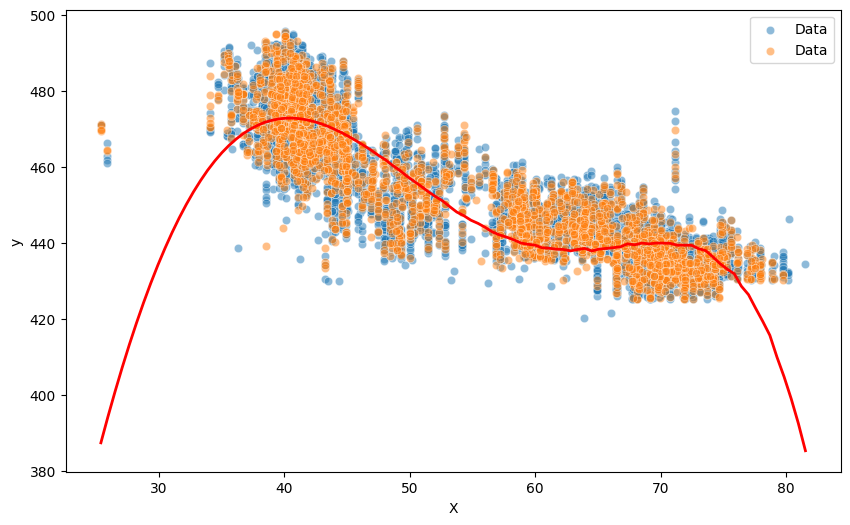

In [62]:
import matplotlib.pyplot as plt

# Generate curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_pred = model.predict(X_range)

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_train, x='X', y='y', alpha=0.5, label='Data')
sns.scatterplot(data=data_test, x='X', y='y', alpha=0.5, label='Data')
plt.plot(X_range, y_pred, color='red', linewidth=2)
plt.show()